# 07 · SpliceAI — predicting splice-disruption effects

Notebooks **02–06** scored *missense* variants — changes that swap one amino acid
for another. But a huge fraction of CFTR disease alleles never touch an amino acid
at all. They live **deep in introns** or are **synonymous** (they change the DNA
but not the protein), and they cause disease by **breaking how the gene is spliced**.

Missense tools (AlphaMissense, EVE, ESM1b, REVEL, PrimateAI) are **completely blind**
to these variants — there is no amino-acid change for them to score. To catch them
you need a different kind of tool: a **splice predictor**.

---

### Why splicing matters for CFTR

Before a gene becomes protein, its RNA is *spliced*: introns are cut out and exons
are stitched together. The cell finds the cut points using short sequence signals —
a **donor site** at the start of an intron and an **acceptor site** at its end. A
single base change can:

- **destroy** a real splice site → an exon gets skipped or an intron kept, and
- **create** a brand-new ("cryptic") splice site → a chunk of intron sneaks into the
  mRNA, usually shifting the reading frame and truncating the protein.

Either way the CFTR protein is wrecked, even though the variant is nowhere near the
coding sequence. Famous real CFTR examples you'll meet in this notebook:

| Legacy name | HGVS (c.) | What it does |
|---|---|---|
| **3849+10kb C>T** | `c.3849+10246C>T` | ~10 kb deep in an intron; creates a *cryptic exon* |
| **2789+5G>A** | `c.2657+5G>A` | weakens a donor site 5 bp into the intron |
| **3272-26A>G** | `c.3140-26A>G` | creates a new acceptor 26 bp upstream of an exon |
| **2988+1G>A** | `c.2988+1G>A` | hits the *canonical* +1 donor base — abolishes splicing |

None of these change an amino acid. All of them cause cystic fibrosis. That is the
whole point of this notebook.

---

### What you'll do here

1. Meet **SpliceAI** and **Pangolin** — deep-learning splice predictors.
2. Load 9 curated CFTR splice variants and tier them by predicted impact.
3. Plot the scores against the published thresholds.
4. Make a **live** call to the real **CADD** web API.
5. Learn a hard-won **data-quality lesson**: a wrong genomic coordinate silently
   breaks everything downstream.
6. See exactly how to swap in **real** SpliceAI / Pangolin scores.


> ✅ **REAL DATA.** This notebook uses **real** precomputed Illumina **SpliceAI v1.3** for the whole CFTR region — **~2.08 M records** (`data/spliceai_cftr_2021_v1.3.csv`, built by the manual-download build cell below): **566,106 SNVs** from the *masked* file plus **1,509,624 indels** from the *raw* file. Keyed by genomic coordinate. **License: CC BY-NC 4.0** (Jaganathan et al. 2019) — cite SpliceAI + Illumina; the raw VCFs stay external.
>
> ⚠ That extract is **mixed masked/raw** — Illumina's `masked.indel` release is commonly a 0-byte failed download, so indels fall back to `raw`. Every row carries `score_type`. The file-choice section below works out exactly what masking does and what the seam costs: **nothing** in the CFTR2 benchmark, one variant in this notebook's worklist.

In [1]:
import sys, pathlib
# `toolkit` is THIS repo's toolkit.py (one directory up) — NOT a pip
# package and nothing to do with gnomAD. The line below puts the repo
# root on sys.path so `import toolkit` resolves to ../toolkit.py.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline

## 1 · SpliceAI — a neural net that reads splice signals

**SpliceAI** (Jaganathan *et al.* 2019, *Cell*, PMID **30661751**) is a deep neural
network that was trained to look at raw DNA sequence and predict, **for every
position**, the probability that it is a splice **acceptor** or **donor**. To score a
*variant*, SpliceAI runs the sequence twice — once as reference, once with the
mutation — and reports how much each probability **changed**. Those changes are the
four **delta scores**, each between **0 and 1**:

| Delta | Name | Meaning |
|---|---|---|
| **DS_AG** | Acceptor **G**ain | variant *creates* a new acceptor site |
| **DS_AL** | Acceptor **L**oss | variant *destroys* an existing acceptor |
| **DS_DG** | Donor **G**ain | variant *creates* a new donor site |
| **DS_DL** | Donor **L**oss | variant *destroys* an existing donor |

A variant might do more than one thing, so SpliceAI gives all four. The single
headline number is:

$$\text{DS\_max} = \max(\text{DS\_AG},\ \text{DS\_AL},\ \text{DS\_DG},\ \text{DS\_DL})$$

**Published thresholds** (the paper's recommended cut-points):

- **DS_max ≥ 0.5** → **high** impact (likely splice-altering)
- **DS_max ≥ 0.2** → **moderate** impact (worth a closer look)
- below 0.2 → **low** / probably no effect

> Interpretation tip: it's the *type* of change that tells the biological story.
> A high **DS_DL** means "a real donor is being lost"; a high **DS_AG** means "a
> cryptic exon may be forming". DS_max alone just says *how* alarming.


### Which precomputed SpliceAI files, and the masked/raw seam

Illumina ships SpliceAI precomputed scores as **four files** — a 2×2 of
{`masked`, `raw`} × {`snv`, `indel`}:

| File | Variant class | Score treatment | Size | Used here |
|---|---|---|---|---|
| **`masked.snv`** | single-nucleotide substitutions | masked | ~28.6 GB | ✅ **SNVs** |
| `raw.snv` | SNVs | raw | ~28.8 GB | fallback only |
| `masked.indel` | small indels | masked | (a broken 0-byte download is common) | ✅ if you have it |
| **`raw.indel`** | small indels | raw | ~69.3 GB | ✅ **indels** (fallback) |

- **snv vs indel** = which variant class is scored. Separate files; the indel file also
  covers the poly-T/TG tract but SpliceAI only scores small indels (≈1-nt insertions,
  ≤4-nt deletions) and does not resolve the TG/T *haplotype* that actually drives IVS8-5T.
- **The VCF:** standard `#CHROM POS ID REF ALT QUAL FILTER INFO`, with the prediction in
  `INFO`: `SpliceAI=ALLELE|SYMBOL|DS_AG|DS_AL|DS_DG|DS_DL|DP_AG|DP_AL|DP_DG|DP_DL`
  (gene + 4 delta scores + 4 delta positions). The build cell below parses that, keeps
  `SYMBOL==CFTR`, and computes `DS_max`. **The masked and raw VCF headers are byte-identical**
  — nothing inside a file says which flavour it is, only the filename does. That is why
  the build cell records `score_type` on every row.

**Why indels are now included.** The missense predictors cannot score an indel at all, so
while this extract was SNV-only, *every* CFTR2 deletion and insertion was invisible to
every tool in the toolkit — including **F508del**, the most common CF variant in the
world. It is in the indel file: `7-117559590-ATCT-A`, **DS_max = 0.01**. That is the
correct answer (F508del is a protein-folding defect, not a splice one) and it is worth
having explicitly rather than as a missing row. predict/13 builds on exactly this point.

---

### raw vs masked — what the difference actually is

Illumina's README FAQ:

> "The raw files also include splicing changes corresponding to strengthening annotated
> splice sites and weakening unannotated splice sites, which are typically much less
> pathogenic than weakening annotated splice sites and strengthening unannotated splice
> sites. The delta scores of such splicing changes are set to 0 in the masked files. We
> recommend using raw files for alternative splicing analysis and masked files for
> variant interpretation."

Masking is an **annotation filter applied after the model runs** — not a different model,
not a rescaling. It zeroes the two biologically *backwards* directions:

| Direction | What it would mean | Masked? |
|---|---|---|
| **gain at an annotated site** | makes a real splice site stronger | → **0** |
| **loss at an unannotated position** | weakens something that was never a site | → **0** |
| loss at an annotated site | destroys a real splice site | kept |
| gain at an unannotated position | creates a cryptic site | kept |

The two kept rows are the two ways splicing actually breaks (the same two this notebook
opened with). Measured across all **566,106** CFTR SNVs, joining the masked and raw files
by coordinate:

| delta | raw > 0 | zeroed by masking | % |
|---|---|---|---|
| DS_AG (acceptor gain) | 18,567 | 1,320 | 7.1% |
| DS_AL (acceptor loss) | 17,599 | 15,204 | **86.4%** |
| DS_DG (donor gain) | 14,487 | 1,247 | 8.6% |
| DS_DL (donor loss) | 12,770 | 10,660 | **83.5%** |

Two properties worth knowing, both verified on those 566,106 variants:

- **All-or-nothing** — *zero* partial changes. A delta is either untouched or set to
  exactly 0. So a masked score is always a genuine model output, never a shrunk one.
- **One-directional** — masked never exceeds raw, in any variant. `raw >= masked` always.

The loss/gain asymmetry is exactly what the rule predicts: almost no position in a gene is
an annotated splice site, so most *loss* deltas point at non-sites and get zeroed, while
*gain* deltas are only zeroed in the rare case they land on a real site.

### Does the seam change any conclusion here? Measurably, almost none

- **CFTR2 benchmark (predict/13):** identical either way — SpliceAI in-domain sensitivity
  0.968 / specificity 1.000, same TP/FP/FN/TN, and **0 of 1,311** CFTR2 SNVs cross the 0.5
  cut between masked and raw.
- **The observed gnomAD worklist below:** among its 4,260 SNVs, HIGH goes 164 → 165 on raw.
  The one variant that moves, `c.2013A>G`, does so entirely on `DS_AL 0.52` at `DP_AL +2` —
  an acceptor loss two bases away, which masking zeroed because that position is not an
  annotated acceptor. It is precisely the false positive masking exists to remove.
- Region-wide, 113 of the 566,106 SNVs cross the cut — but nearly all are *theoretical*
  substitutions nobody has observed, which is why they vanish on intersection with CFTR2.

**So this extract stays masked**, following Illumina's recommendation for variant
interpretation. If you want a fully consistent extract, the fix is to re-download
`masked.indel`, not to drop to raw — the build cell below prefers it automatically once the
file is non-empty. Either way, check `score_type` before comparing two scores: `raw >=
masked` always, so a masked-vs-raw difference is a reporting convention, never biology.

**Remaining coverage limit:** deep-intronic variants like `3849+10kb` fall outside the
precomputed **distance window** (default −D 50) — that gap is about *distance*, and is
neither a masked/raw nor an SNV/indel issue.

## Building the REAL data — a manual download + a targeted seek (not a 28 GB read)

Illumina's precomputed SpliceAI files have no API and are far too large to
download in full inside a notebook (28.6–69.3 GB each). **You must fetch these
yourself:**

1. Go to the Illumina BaseSpace share
   <https://basespace.illumina.com/s/otSPW8hnhaZR> ("Predicting splicing from
   primary sequence" / `genome_scores_v1.3`) and download, into `data/`:
   - `spliceai_scores.masked.snv.hg38.vcf.gz` **and its `.tbi` index** (~28.6 GB) — SNVs
   - `spliceai_scores.raw.indel.hg38.vcf.gz` **and its `.tbi` index** (~69.3 GB) — indels
     (`masked.indel` is commonly a 0-byte failed download; the cell below prefers it
     automatically if you do have a working copy, and falls back to `raw.indel`)
2. Leave the `.gz` files compressed — the cell below never decompresses them.

**How it stays fast despite the file sizes:** each `.tbi` index tells us the
*byte offset* where chromosome 7 begins, so we `seek()` straight there with
`Bio.bgzf` and read only the ~200 kb CFTR window — not 28–69 GB. (`pysam` would
normally do this tabix seek, but it doesn't build on Windows, so the cell parses
the `.tbi` binary format by hand.) Every row keeps `score_type` (`masked`/`raw`)
and `variant_class` (`snv`/`indel`) so a masked score is never silently compared
to a raw one — see the seam analysis above for why that distinction matters.

License: **CC BY-NC 4.0** (Jaganathan et al. 2019) — the raw VCFs stay external,
never committed; cite SpliceAI + Illumina if you publish the derived extract.

In [2]:
import gzip, struct
from Bio import bgzf

DATA_DIR = pathlib.Path.cwd().parent / "data"
SPLICEAI_TSV = DATA_DIR / "spliceai_cftr_2021_v1.3.csv"
REGION_START, REGION_END = 117_470_000, 117_670_000   # GRCh38, safe superset of CFTR
LIDX_SHIFT = 14                                        # tabix linear-index window = 16 kb


def _pick(*names):
    """First of `names` that exists in data/ and is non-empty (a 0-byte masked.indel
    is a common failed download; silently reading it would look like 'no indels'
    rather than 'the file never downloaded')."""
    for n in names:
        p = DATA_DIR / n
        if p.exists() and p.stat().st_size > 0:
            return p
    return None


def _tbi_start_offset(tbi_path, region_start=REGION_START):
    """Parse the .tbi index by hand (pysam doesn't build on Windows) and return
    (contig_name, bgzf virtual offset) to seek to instead of reading from byte 0."""
    raw = gzip.open(tbi_path, "rb").read()
    off = [0]

    def take(fmt):
        sz = struct.calcsize(fmt)
        v = struct.unpack_from(fmt, raw, off[0]); off[0] += sz
        return v

    (magic,) = take("<4s")
    assert magic == b"TBI\x01", magic
    n_ref, _fmt, _cs, _cb, _ce, _meta, _skip, l_nm = take("<8i")
    names = [n.decode() for n in raw[off[0]:off[0] + l_nm].split(b"\x00")[:-1]]
    off[0] += l_nm
    target = next((names.index(c) for c in ("7", "chr7") if c in names), None)
    if target is None:
        raise SystemExit(f"no chr7 contig in tbi; sample names: {names[:6]}")
    for r in range(n_ref):
        (n_bin,) = take("<i")
        for _ in range(n_bin):
            _bin, n_chunk = take("<Ii")
            off[0] += n_chunk * 16
        (n_intv,) = take("<i")
        intv = struct.unpack_from("<%dQ" % n_intv, raw, off[0]); off[0] += n_intv * 8
        if r == target:
            li = min(region_start >> LIDX_SHIFT, n_intv - 1)
            voff = next((intv[i] for i in range(li, n_intv) if intv[i]), 0)
            return names[target], voff
    raise SystemExit("target ref not reached")


def _scan(vcf_path):
    """Seek to the CFTR region in one precomputed VCF and yield parsed score rows."""
    score_type = "masked" if ".masked." in vcf_path.name else "raw"
    variant_class = "indel" if ".indel." in vcf_path.name else "snv"
    contig, voff = _tbi_start_offset(pathlib.Path(str(vcf_path) + ".tbi"))
    print(f"  {vcf_path.name}  (contig={contig}, {score_type}/{variant_class})")
    rows = []
    reader = bgzf.BgzfReader(str(vcf_path), "rb")
    reader.seek(voff)
    for bline in reader:
        line = bline.decode() if isinstance(bline, bytes) else bline
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        if f[0] != contig:
            break
        pos = int(f[1])
        if pos < REGION_START:
            continue
        if pos > REGION_END:
            break
        info = f[7]
        if "SpliceAI=" not in info:
            continue
        field = next(x for x in info.split(";") if x.startswith("SpliceAI="))[len("SpliceAI="):]
        parts = field.split("|")
        if len(parts) < 6 or parts[1] != "CFTR":
            continue
        try:
            ds = [float(parts[i]) for i in (2, 3, 4, 5)]
        except ValueError:
            continue
        rows.append({"chrom": f[0], "pos": pos, "ref": f[3], "alt": f[4],
                     "DS_AG": ds[0], "DS_AL": ds[1], "DS_DG": ds[2], "DS_DL": ds[3],
                     "spliceai_ds_max": round(max(ds), 4),
                     "variant_class": variant_class, "score_type": score_type, "source": "REAL"})
    reader.close()
    print(f"    -> {len(rows):,} CFTR {variant_class} records")
    return rows


if SPLICEAI_TSV.exists():
    print(f"already built -> {SPLICEAI_TSV.name} (delete to rebuild)")
else:
    snv_vcf = _pick("spliceai_scores.masked.snv.hg38.vcf.gz", "spliceai_scores.raw.snv.hg38.vcf.gz")
    indel_vcf = _pick("spliceai_scores.masked.indel.hg38.vcf.gz", "spliceai_scores.raw.indel.hg38.vcf.gz")
    if snv_vcf is None and indel_vcf is None:
        raise FileNotFoundError(
            "No SpliceAI VCF found in data/ -- see the markdown above for the "
            "BaseSpace download links (each needs its .tbi index alongside it).")
    rows = []
    print("reading:")
    if snv_vcf is None:
        print("  ! no SNV VCF found -- extract will have no SNVs")
    else:
        rows += _scan(snv_vcf)
    if indel_vcf is None:
        print("  ! no non-empty indel VCF found -- extract will have no indels")
    else:
        rows += _scan(indel_vcf)
    df = pd.DataFrame(rows)
    df.to_csv(SPLICEAI_TSV, index=False)
    print(f"\nREAL SpliceAI CFTR records written: {len(df):,} -> {SPLICEAI_TSV.relative_to(DATA_DIR.parent)}")
    if len(df) and df["score_type"].nunique() > 1:
        print("  ⚠ MIXED masked/raw extract -- rows carry score_type; see the seam analysis above.")

already built -> spliceai_cftr_2021_v1.3.csv (delete to rebuild)


## Load the REAL SpliceAI scores and tier them

`spliceai_ds_max` is SpliceAI's **delta score**: a probability from **0 to 1** that the
variant disrupts a splice site (`DS_max` = the largest of the four acceptor/donor
gain/loss deltas). Tier: **≥ 0.5 high**, **≥ 0.2 moderate**. Many strong variants — SNVs
right at a canonical donor/acceptor site — **saturate at exactly 1.0**, so when we sort
descending the top of the list is all `1.0` (the ceiling, not a bug).

In [3]:
splice = tk.load_spliceai()      # REAL — ~2.08M CFTR records (Illumina v1.3), built above
print(f"{len(splice):,} REAL SpliceAI CFTR records | source: {splice['source'].unique().tolist()}")
print(splice.groupby(['variant_class', 'score_type']).size().to_string())
def tier(x):
    return "HIGH" if x >= 0.5 else ("MODERATE" if x >= 0.2 else "LOW")
splice["tier"] = splice["spliceai_ds_max"].apply(tier)
print()
print(pd.crosstab(splice["variant_class"], splice["tier"]).to_string())
splice.sort_values("spliceai_ds_max", ascending=False).head(8)[
    ["chrom","pos","ref","alt","variant_class","spliceai_ds_max","tier"]]

2,075,730 REAL SpliceAI CFTR records | source: ['REAL']
variant_class  score_type
indel          raw           1509624
snv            masked         566106



tier           HIGH      LOW  MODERATE
variant_class                         
indel          3002  1499166      7456
snv             977   563461      1668


,chrom,pos,ref,alt,variant_class,spliceai_ds_max,tier
1352953,7,117578318,GAATA,G,indel,1.0,HIGH
1449220,7,117590352,G,GG,indel,1.0,HIGH
1449225,7,117590352,GAGCA,G,indel,1.0,HIGH
1449212,7,117590351,A,AG,indel,1.0,HIGH
1008933,7,117535316,G,GT,indel,1.0,HIGH
1549342,7,117602867,AG,A,indel,1.0,HIGH
2045292,7,117664861,G,GG,indel,1.0,HIGH
1549344,7,117602867,AGTA,A,indel,1.0,HIGH


## The real splice analysis — score *observed* CFTR non-coding variants

The payoff: join real SpliceAI onto the **~4,717 observed** gnomAD non-coding CFTR variants to build a real splice worklist — instead of the demo's 9.

In [4]:
nc = tk.load_gnomad_noncoding()
vid = nc["variant_id"].str.split("-", expand=True)
nc["chrom"], nc["pos"], nc["ref"], nc["alt"] = vid[0], vid[1].astype(int), vid[2], vid[3]
sp = tk.load_spliceai(); sp["chrom"] = sp["chrom"].astype(str)
a2 = nc.merge(sp[["chrom","pos","ref","alt","spliceai_ds_max"]],
              on=["chrom","pos","ref","alt"], how="inner")
print(f"observed non-coding CFTR variants with a real SpliceAI score: {len(a2):,} / {len(nc):,}")
print("HIGH (>=0.5):", int((a2.spliceai_ds_max >= 0.5).sum()),
      "| MODERATE (0.2-0.5):", int(((a2.spliceai_ds_max >= 0.2) & (a2.spliceai_ds_max < 0.5)).sum()))
a2.sort_values("spliceai_ds_max", ascending=False).head(10)[
    ["variant_id","hgvs_c","spliceai_ds_max"]]

observed non-coding CFTR variants with a real SpliceAI score: 4,535 / 4,717
HIGH (>=0.5): 173 | MODERATE (0.2-0.5): 86


,variant_id,hgvs_c,spliceai_ds_max
4008,7-117652932-G-T,c.3963+1G>T,1.0
1734,7-117559462-A-G,c.1393-2A>G,1.0
1735,7-117559463-G-A,c.1393-1G>A,1.0
1084,7-117536674-G-A,c.869+1G>A,1.0
4007,7-117652932-G-C,c.3963+1G>C,1.0
1085,7-117536675-T-A,c.869+2T>A,1.0
2651,7-117602825-G-C,c.2620-1G>C,1.0
1066,7-117536547-G-T,c.744-1G>T,1.0
4260,7-117665457-A-G,c.4137-2A>G,1.0
4261,7-117665458-G-A,c.4137-1G>A,1.0


## Why the demo's 9 curated variants don't reproduce (a lesson)

The table below joins the 9 hand-curated demo variants onto the **real** SpliceAI extract
by coordinate, and puts two columns side by side:

- **`demo_dsmax`** — the *hand-authored, illustrative* value baked into the demo table
  (made up for teaching; **not** real model output).
- **`real_dsmax`** — the *actual* SpliceAI score looked up from the real extract.

They **don't match**: only 2 join, and those score **~0**, not the demo's 0.76/0.91. Two
reasons — both real limitations:

1. **Wrong coordinates** — several demo coords are hand-entered and don't match GRCh38.
2. **Precomputed distance window** — the release only scores within ±50 bp of the
   annotated transcript, so famous deep-intronic alleles like `3849+10kb` aren't in it at
   all. For those, run SpliceAI locally with a larger `-D`, or use the Broad lookup. (Note
   this is a *distance* limit — it is not fixed by including the indel files.)

So the demo's tidy numbers were **illustrative only** — exactly why REAL data matters.

In [5]:
demo = tk.load_splice_demo(); demo["chrom"] = demo["chrom"].astype(str)
demo = demo.rename(columns={"spliceai_ds_max": "demo_dsmax"})  # hand-authored, NOT real SpliceAI
chk = demo.merge(sp[["chrom","pos","ref","alt","spliceai_ds_max"]]
                 .rename(columns={"spliceai_ds_max": "real_dsmax"}),
                 on=["chrom","pos","ref","alt"], how="left")
chk[["legacy_name","variant_type","demo_dsmax","real_dsmax","cftr2_class"]]

,legacy_name,variant_type,demo_dsmax,real_dsmax,cftr2_class
0,3849+10kb C>T,deep_intronic,0.81,NaN,CF-causing
1,2789+5G>A,splice_site,0.91,NaN,CF-causing
2,3272-26A>G,deep_intronic,0.76,0.00,CF-causing
3,2657+3A>G,splice_site,0.88,NaN,CF-causing
4,IVS8_5T,deep_intronic,0.31,0.04,VUS
5,2988+1G>A,splice_site,0.97,NaN,CF-causing
6,1811+1.6kbA>G,deep_intronic,0.68,NaN,CF-causing
7,syn context,synonymous,0.18,NaN,VUS
8,c.2657+120C>T,deep_intronic,0.54,NaN,VUS


## Distribution of real SpliceAI scores (observed non-coding set)

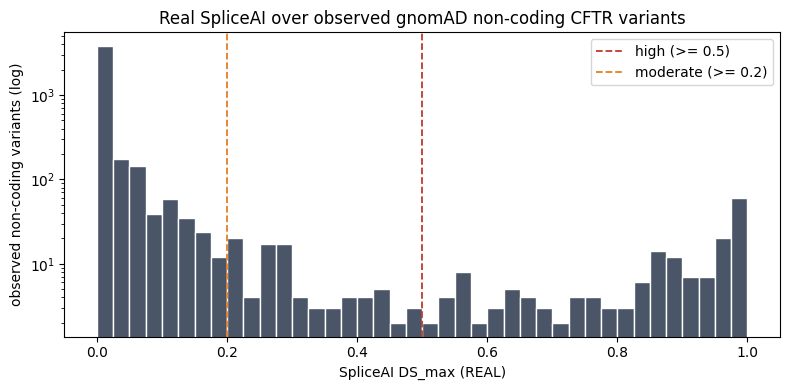

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(a2["spliceai_ds_max"], bins=40, color="#4a5568", edgecolor="white")
ax.axvline(0.5, ls="--", color="#c0392b", lw=1.3, label="high (>= 0.5)")
ax.axvline(0.2, ls="--", color="#e67e22", lw=1.3, label="moderate (>= 0.2)")
ax.set_yscale("log")
ax.set_xlabel("SpliceAI DS_max (REAL)"); ax.set_ylabel("observed non-coding variants (log)")
ax.set_title("Real SpliceAI over observed gnomAD non-coding CFTR variants")
ax.legend(); fig.tight_layout(); plt.show()

## How to refresh the real SpliceAI data

Already wired in: the build cell above pulls the CFTR region from the precomputed Illumina VCF (via the `.tbi` index) → `data/spliceai_cftr_2021_v1.3.csv` → `tk.load_spliceai()`. To refresh, drop a newer precomputed VCF into `data/` and delete the extract so the cell rebuilds it. For deep-intronic variants beyond the precomputed coverage, run SpliceAI locally (`spliceai -D ...`) or use the Broad SpliceAI-lookup.

## Example: the shared splice worked-example panel, scored by **SpliceAI**

The same fixed panel of famous CFTR **splice** variants runs through every splice tool
(tools/07–09), so you can follow one set of variants across the series. The
variant list is `tk.A2_KNOWN_CDNA` (shared in `toolkit.py`); the **scoring is shown
inline below** so you can see exactly how SpliceAI is joined onto it.

In [7]:
# Splice panel = known CF splice alleles, joined by their AUTHORITATIVE CFTR2 GRCh38
# coordinates (tk.A2_KNOWN_CDNA), NOT the demo's hand-entered ones.
cf = tk.load_cftr2()
a2 = cf[cf['cdna_name'].isin(tk.A2_KNOWN_CDNA)].dropna(subset=['grch38_pos'])
sp = tk.load_spliceai()
rows = []
for _, v in a2.iterrows():
    pos = int(v['grch38_pos'])
    hit = sp[(sp['pos'] == pos) & (sp['ref'] == v['grch38_ref']) & (sp['alt'] == v['grch38_alt'])]
    rows.append({'cdna_name': v['cdna_name'], 'legacy_name': v['legacy_name'], 'pos': pos,
                 'spliceai_ds_max': round(float(hit['spliceai_ds_max'].iloc[0]), 4) if len(hit) else None})
pd.DataFrame(rows)

,cdna_name,legacy_name,pos,spliceai_ds_max
0,c.3718-2477C>T,3849+10kbC->T,117639961,0.16
1,c.2657+5G>A,2789+5G->A,117602868,0.93
2,c.3140-26A>G,3272-26A->G,117611555,0.99
3,c.2988+1G>A,3120+1G->A,117606754,0.99
4,c.1680-886A>G,1811+1634A->G,117589467,0.74


## Key takeaways

1. **SpliceAI is REAL** — ~2.08 M CFTR records (Illumina v1.3), `source == REAL`:
   566 k SNVs (masked) **plus** 1.51 M indels (raw).
2. **Indels are included**, which matters more than the row count suggests: no missense
   predictor can score an indel, so these are variants that would otherwise have *no*
   prediction from anything. F508del scores **DS_max 0.01** — correctly, it is a folding
   defect, not a splice one (predict/13).
3. The extract is **mixed masked/raw** (Illumina's `masked.indel` is usually a broken
   download), so every row carries `score_type`. Masking is an all-or-nothing annotation
   filter — it zeroes gains at real splice sites and losses at non-sites — and `raw >=
   masked` always. It changes **nothing** in the CFTR2 benchmark and moves exactly one
   variant in the worklist below, so this extract stays masked per Illumina's advice.
4. The **real splice worklist**: **4,535** of the 4,717 observed non-coding CFTR variants
   scored, **173 HIGH** and 86 MODERATE — a real worklist, not 9 demo rows. (It grew from
   4,260 / 164 once indels were included.)
5. The demo curated variants mostly **don't reproduce** (coordinate errors + the
   precomputed distance window) — the honest lesson of this notebook.
6. Scores are **CC BY-NC 4.0** — cite SpliceAI/Illumina; keep the raw VCFs external.

**Next:** tools/08 — **Pangolin**, the independent splice model, run locally.